<a href="https://colab.research.google.com/github/masamnx21/numpymatplotlib/blob/main/Copy_of_numpymatplotlib_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#name: Nel Masamune
#numpy/matplotlib Mini-Project
#MA/CS 341- Scientific Computing

In [2]:
#follow linked parallel job tutorial
#importing packages
import numpy as np
import sys
import datetime
import math
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#function for generating random numbers and determining if they're inside the circle
def inside_circle(total_count):
  x = np.random.uniform(size=total_count)
  y = np.random.uniform(size=total_count)
  radii = np.sqrt(x*x + y*y)
  #counting how many inside the circle
  count = len(radii[np.where(radii<=1.0)])
  return count

In [4]:
#defining function to output approximation of pi, time and memory commitment, and relative error
def pi_approx(i):
  n_samples = 10 ** i
  start_time = datetime.datetime.now()
  counts = inside_circle(n_samples)
  end_time = datetime.datetime.now()
  elapsed_time = (end_time - start_time).total_seconds()
  my_pi = 4.0 * counts / n_samples
  size_of_float = np.dtype(np.float64).itemsize
  memory_required = 3 * n_samples * size_of_float / (1024**3)
  data = [n_samples, my_pi, memory_required, elapsed_time, abs(my_pi-math.pi)]
  return data
#  return (my_pi, memory_required, elapsed_time, abs(my_pi-math.pi))

In [5]:
#outputing approx pi's, rel. error, etc. for larger n's
#make it loop 10^n, from 100<n<10^8 -running 10^9 crashed my google colab page

#making and using dictionary to store pi data
pi_data = {}
variables = ('sample size', 'pi', 'memory', 'time', 'error')
for i, name in enumerate(variables):
    pi_data[name] = []


#generating pi approximation and related data
i = 2
while i < 9:
    pii = pi_approx(i)
    #printing data
    print("Sample size: {}, Pi: {}, memory: {} GiB, time: {} s, error: {}".format(pii[0], pii[1], pii[2],
                                                  pii[3], pii[4]))
    #saving data to dictionary
    for j, name in enumerate(variables):
        pi_data[name].append(pii[j])
    i = i + 1

Sample size: 100, Pi: 3.0, memory: 2.2351741790771484e-06 GiB, time: 0.005919 s, error: 0.14159265358979312
Sample size: 1000, Pi: 3.168, memory: 2.2351741790771484e-05 GiB, time: 0.000201 s, error: 0.026407346410207033
Sample size: 10000, Pi: 3.158, memory: 0.00022351741790771484 GiB, time: 0.00088 s, error: 0.016407346410206802
Sample size: 100000, Pi: 3.14852, memory: 0.0022351741790771484 GiB, time: 0.010869 s, error: 0.006927346410206869
Sample size: 1000000, Pi: 3.139968, memory: 0.022351741790771484 GiB, time: 0.096806 s, error: 0.0016246535897930237
Sample size: 10000000, Pi: 3.1420828, memory: 0.22351741790771484 GiB, time: 1.48671 s, error: 0.0004901464102067266
Sample size: 100000000, Pi: 3.14174576, memory: 2.2351741790771484 GiB, time: 6.71493 s, error: 0.00015310641020693794


In [6]:
#output to .csv file using pandas
row_labels = [0, 1, 2, 3, 4, 5, 6]
df = pd.DataFrame(data=pi_data, index=row_labels)
df.to_csv('pi_approx.csv')

In [7]:
#importing .csv file using numpy's genfromtxt
pi = np.genfromtxt('pi_approx.csv', delimiter=',', encoding='UTF-8', skip_header = 1, names=['index', 'sample size', 'pi', 'memory', 'time', 'error'])

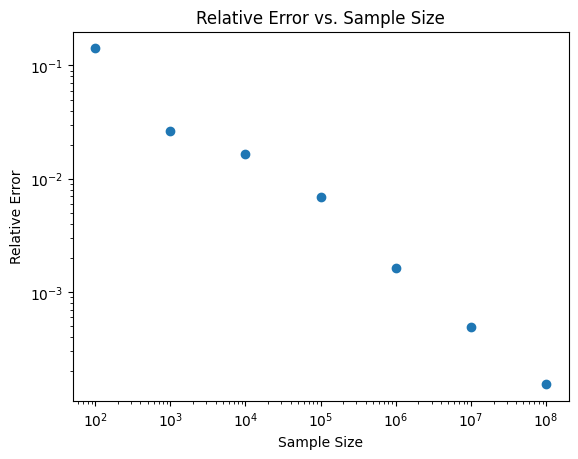

-0.47732919594708484 0.1384750232804996


In [8]:
#graphing N vs error
x = pi['sample_size']
y = pi['error']
plt.scatter(x, y)
plt.xlabel('Sample Size')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Relative Error')
plt.title('Relative Error vs. Sample Size')
plt.show()

#printing trendline of N vs error
#z[0] : slope
#z[1] : intercept
z = np.polyfit(np.log(x), np.log(y), 1)
p = np.poly1d(z)
print(z[0], z[1])

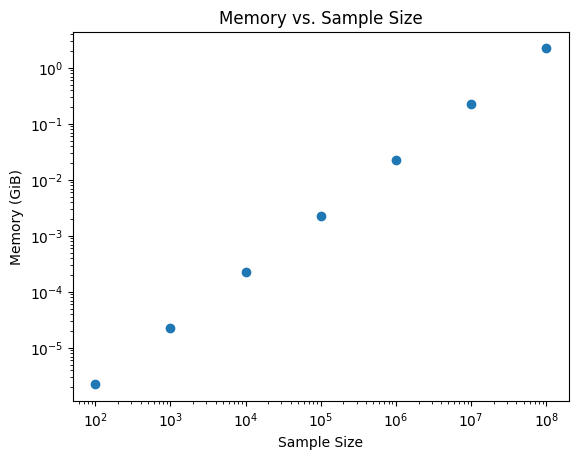

1.0000000000000007 -17.616361586450424


In [9]:
#graphing N vs memory
x = pi['sample_size']
y = pi['memory']
plt.scatter(x, y)
plt.xlabel('Sample Size')
plt.ylabel('Memory (GiB)')
plt.xscale('log')
plt.yscale('log')
plt.title('Memory vs. Sample Size')
plt.show()

#printing trendline of N vs memory
#z[0] : slope
#z[1] : intercept
z = np.polyfit(np.log(x), np.log(y), 1)
p = np.poly1d(z)
print(z[0], z[1])

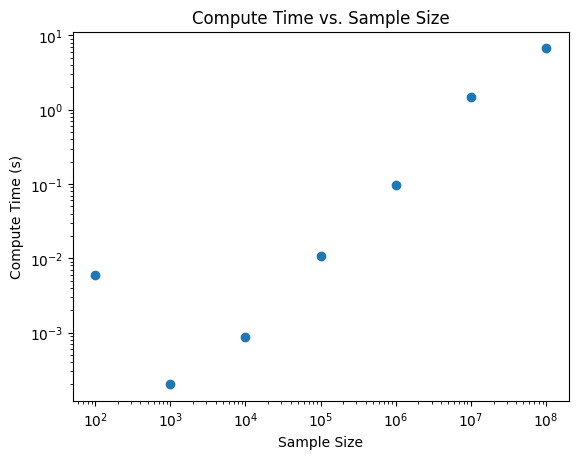

0.6765664093933494 -11.394025774134203


In [10]:
#graphing N vs time
x = pi['sample_size']
y = pi['time']
plt.scatter(x, y)
plt.xlabel('Sample Size')
plt.ylabel('Compute Time (s)')
plt.xscale('log')
plt.yscale('log')
plt.title('Compute Time vs. Sample Size')
plt.show()

#printing trendline of N vs time
#z[0] : slope
#z[1] : intercept
z = np.polyfit(np.log(x), np.log(y), 1)
p = np.poly1d(z)
print(z[0], z[1])

In [11]:
#answer questions in text-based group in notebook
'''
a.The relative error drops off in a pretty linear fashion ignoring the two large outliers. The an increase in N by a factor of 10 does not correspond to a
an error decrease by a factor of 10, in fact the slope calculated is -0.4; however, this is probably very skewed by the two outliers.
b. There is a strong linear correlation between memory and sample size, and an increase in the sample size by a factor of 10 results in a increase in
the memory by a factor of 10 as well. The slope was calculated to be 1.
c.The time showed a less linear and more polynomial/quadratic slope. I wasn't able to figure out how to fit a non-linear trendline, and I was also not
able to calculate the trendline of the data. This is due to the two 'zero seconds' values I got when measuring computing time. This changes as I rerun the code.
I didn't expect it to be linear, as I think these calculations may correspond with a different O time calculation.
'''

"\na.The relative error drops off in a pretty linear fashion ignoring the two large outliers. The an increase in N by a factor of 10 does not correspond to a\nan error decrease by a factor of 10, in fact the slope calculated is -0.4; however, this is probably very skewed by the two outliers.\nb. There is a strong linear correlation between memory and sample size, and an increase in the sample size by a factor of 10 results in a increase in\nthe memory by a factor of 10 as well. The slope was calculated to be 1.\nc.The time showed a less linear and more polynomial/quadratic slope. I wasn't able to figure out how to fit a non-linear trendline, and I was also not\nable to calculate the trendline of the data. This is due to the two 'zero seconds' values I got when measuring computing time. This changes as I rerun the code.\nI didn't expect it to be linear, as I think these calculations may correspond with a different O time calculation.\n"